Camel class index: 354 -> Arabian camel

Image: /content/camel-1536x580.jpg
Original size: 1536 x 580
Response map shape: torch.Size([1, 1000, 19, 48])
Top-activated class index: 684
Top-activated class label: ocarina
Using class 354 -> Arabian camel
score_map shape: (19, 48)
max(score) = 1.000, relative threshold = 0.100
Bounding box (x, y, w, h): (1104, 106, 159, 186)


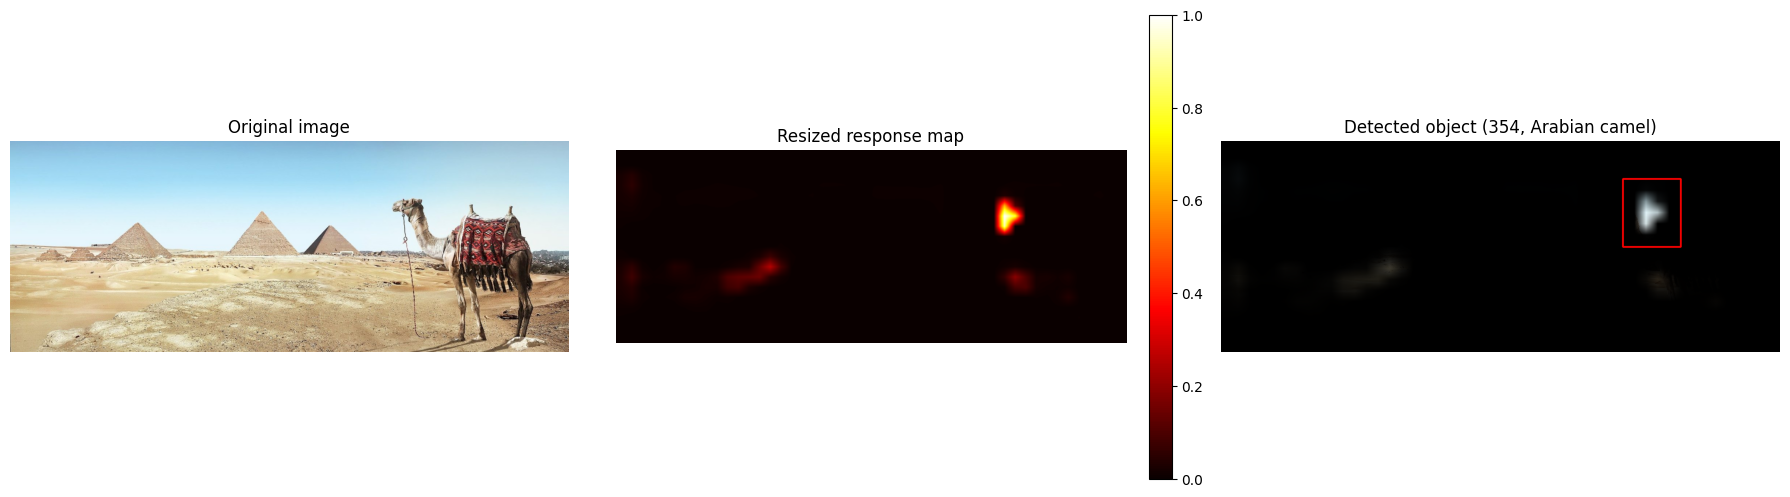

In [ ]:
# ===========================
# 1. Imports
# ===========================
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15, 5)

# ===========================
# 2. FCResNet18 definition
# ===========================
class FCResNet18(nn.Module):
    """
    Fully convolutional ResNet18:
    - replaces first maxpool with avgpool
    - replaces GAP + FC with 1x1 conv (512 -> 1000)
    - copies pretrained FC weights into 1x1 conv
    """
    def __init__(self, num_classes=1000, pretrained=True):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        base = resnet18(weights=weights)

        # Copy layers up to layer4
        self.conv1 = base.conv1
        self.bn1   = base.bn1
        self.relu  = base.relu

        # maxpool -> avgpool
        self.pool  = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = base.layer1  # conv2_x
        self.layer2 = base.layer2  # conv3_x
        self.layer3 = base.layer3  # conv4_x
        self.layer4 = base.layer4  # conv5_x

        # 1x1 conv classifier instead of GAP + FC
        self.classifier = nn.Conv2d(512, num_classes, kernel_size=1, stride=1, padding=0)

        if pretrained:
            fc_w = base.fc.weight.data    # [1000, 512]
            fc_b = base.fc.bias.data      # [1000]
            self.classifier.weight.data.copy_(fc_w.view(num_classes, 512, 1, 1))
            self.classifier.bias.data.copy_(fc_b)

        # Save categories (class names) from weights meta
        self.categories = weights.meta["categories"] if pretrained else None

    def forward(self, x):
        # x : [B, 3, H, W]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)          # [B, 64, H/4, W/4]

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)        # [B, 512, n, m]

        x = self.classifier(x)    # [B, 1000, n, m]
        return x

# ===========================
# 3. Build model & transforms
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FCResNet18(pretrained=True).to(device)
model.eval()

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

categories = model.categories  # list of 1000 class names

# Find the index for "Arabian camel" in the torchvision categories
camel_name = "Arabian camel"
camel_class = categories.index(camel_name)
print("Camel class index:", camel_class, "->", categories[camel_class])

# ===========================
# 4. Helper: run detection on one image
# ===========================
def detect_and_show(image_path, class_idx, title_prefix="Detected object",
                    REL_THRESH=0.15, DILATE_SIZE=35):
    """
    image_path : path to image file
    class_idx  : ImageNet class index whose response map we use
    REL_THRESH : keep pixels >= REL_THRESH * max(score)
    DILATE_SIZE: kernel size used to dilate the mask
    """
    # ---- Load image (PIL for preprocessing, OpenCV for drawing) ----
    pil_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = pil_img.size
    print(f"\nImage: {image_path}")
    print(f"Original size: {orig_w} x {orig_h}")

    input_tensor = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)            # [1,1000,n,m]
        probs  = torch.softmax(logits, dim=1)   # softmax over classes

    print("Response map shape:", probs.shape)
    B, C, n, m = probs.shape

    # For inspection: which class has the highest activation overall?
    class_max = probs.view(C, -1).max(dim=1).values
    top_class = class_max.argmax().item()
    print("Top-activated class index:", top_class)
    print("Top-activated class label:", categories[top_class])

    # ---- Get score map for chosen class ----
    class_label = categories[class_idx]
    print(f"Using class {class_idx} -> {class_label}")

    score_map = probs[0, class_idx, :, :].cpu().numpy()  # [n,m]
    print("score_map shape:", score_map.shape)

    # ---- Resize score map to original image size ----
    score_resized = cv2.resize(score_map, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)

    # Normalize to [0,1]
    score_norm = score_resized - score_resized.min()
    score_norm = score_norm / (score_norm.max() + 1e-8)

    # ===========================
    # 5. Relative thresholding & bbox
    # ===========================
    # Smooth slightly (helps to avoid isolated pixels)
    score_blur = cv2.GaussianBlur(score_norm.astype(np.float32), (9, 9), 0)

    max_val = score_norm.max()
    thr_val = REL_THRESH * max_val
    print(f"max(score) = {max_val:.3f}, relative threshold = {thr_val:.3f}")

    mask = (score_blur >= thr_val).astype(np.uint8)  # 0/1
    # Dilate to grow region

    mask = (score_norm >= 0.15 * max_val).astype(np.uint8)
    kernel = np.ones((75, 75), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)

    mask_uint8 = (mask * 255).astype(np.uint8)

    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    rect = None
    if len(contours) == 0:
        print("No contour found – try lowering REL_THRESH.")
    else:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        rect = (x, y, w, h)
        print("Bounding box (x, y, w, h):", rect)

    # ===========================
    # 6. Mask + visualization
    # ===========================
    # Original image in BGR (for OpenCV ops)
    orig_bgr = cv2.imread(image_path)
    orig_bgr = cv2.resize(orig_bgr, (orig_w, orig_h))

    # Normalize score map again for visualization
    score_vis = score_norm / (score_norm.max() + 1e-8)

    # Apply as mask
    score_3c = np.stack([score_vis]*3, axis=-1)  # [H,W,3]
    masked = (orig_bgr.astype(np.float32) * score_3c).astype(np.uint8)

    # Draw bbox on masked image
    if rect is not None:
        x, y, w, h = rect
        cv2.rectangle(masked, (x, y), (x + w, y + h), (0, 0, 255), thickness=3)

    # Convert BGR -> RGB for plotting
    orig_rgb   = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    masked_rgb = cv2.cvtColor(masked,   cv2.COLOR_BGR2RGB)

    # Plot
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original image")
    plt.imshow(orig_rgb)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Resized response map")
    plt.imshow(score_vis, cmap="hot")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"{title_prefix} ({class_idx}, {class_label})")
    plt.imshow(masked_rgb)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ===========================
# 6. Run on camel.jpg
# ===========================
camel_image_path = "/content/camel-1536x580.jpg"   # make sure this file exists in the current dir
detect_and_show(camel_image_path, class_idx=camel_class,
                title_prefix="Detected object",
                REL_THRESH=0.10,   # lower -> larger region
                DILATE_SIZE=50)    # larger -> larger box

In [ ]:
!pip install --upgrade sympy

Z = 135 -> limpkin
Z+5 = 140 -> red-backed sandpiper

Image: /content/limpkin480x360.jpg
Original size: 480 x 360
Response map shape: torch.Size([1, 1000, 12, 15])
Top-activated class index: 135
Top-activated class label: limpkin
Using class 135 -> limpkin
score_map shape: (12, 15)
max(score) = 1.000, relative threshold = 0.150
Bounding box (x, y, w, h): (50, 0, 408, 360)


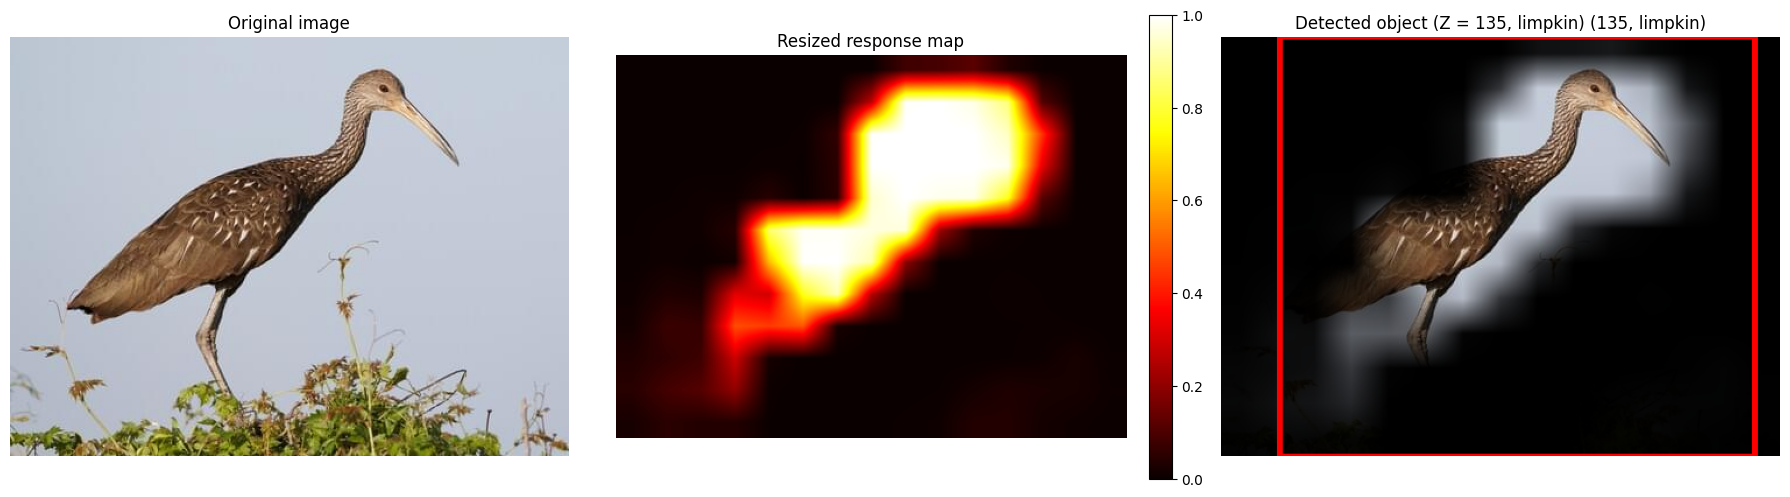


Image: /content/redbacked sandpiper 850x607.webp
Original size: 850 x 607
Response map shape: torch.Size([1, 1000, 19, 27])
Top-activated class index: 140
Top-activated class label: red-backed sandpiper
Using class 140 -> red-backed sandpiper
score_map shape: (19, 27)
max(score) = 1.000, relative threshold = 0.150
Bounding box (x, y, w, h): (299, 103, 283, 343)


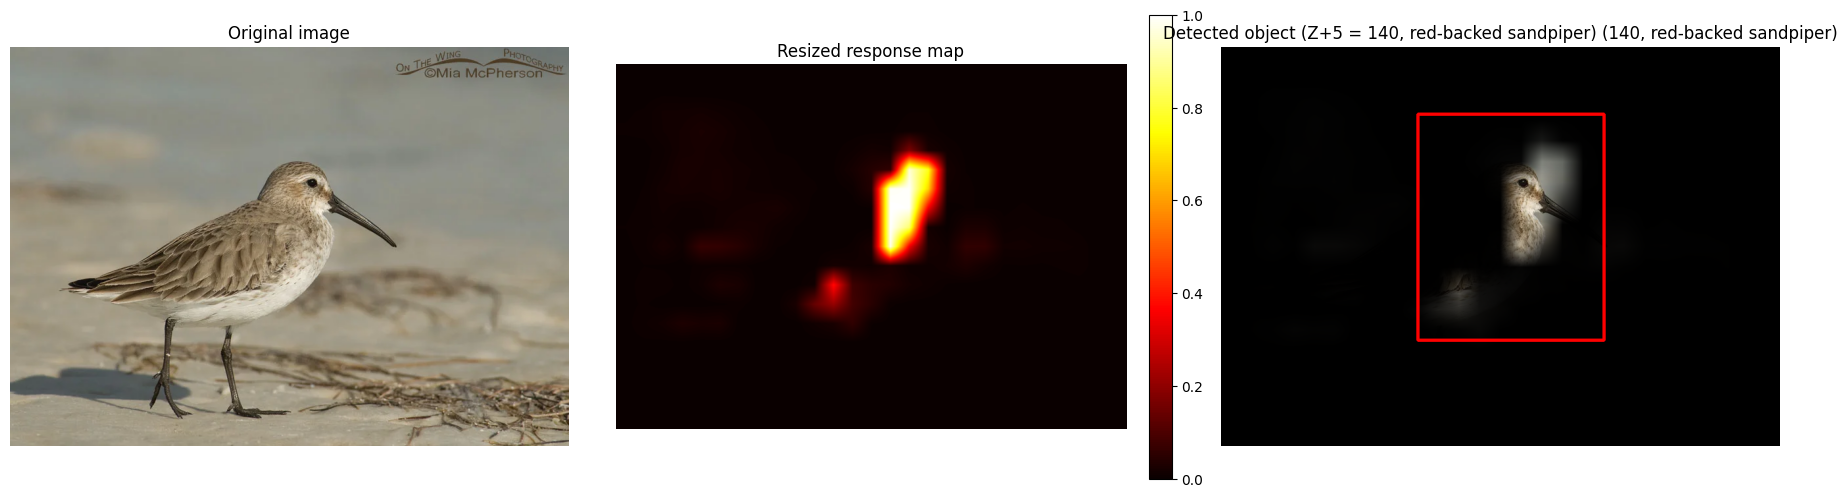

In [ ]:
# ---------- PART 4: Z and Z+5 ----------

Z = 135
Z_plus_5 = 140

print("Z =", Z, "->", categories[Z])
print("Z+5 =", Z_plus_5, "->", categories[Z_plus_5])

# Paths to downloaded images
limpkin_path = "/content/limpkin480x360.jpg"              # 480x360
sandpiper_path = "/content/redbacked sandpiper 850x607.webp"  # 850x607

# Limpkin detection
detect_and_show(
    limpkin_path,
    class_idx=Z,
    title_prefix="Detected object (Z = 135, limpkin)",
    REL_THRESH=0.15,
    DILATE_SIZE=35,
)

# Red-backed sandpiper detection
detect_and_show(
    sandpiper_path,
    class_idx=Z_plus_5,
    title_prefix="Detected object (Z+5 = 140, red-backed sandpiper)",
    REL_THRESH=0.15,
    DILATE_SIZE=35,
)

In [ ]:
def auto_detect_and_show(image_path, title_prefix="Detected object (auto)",
                         REL_THRESH=0.15, DILATE_SIZE=35):
    """
    Chooses the class whose response map has the highest activation globally
    and then runs the same detection pipeline.
    """
    from PIL import Image

    pil_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = pil_img.size
    print(f"\nImage: {image_path}")
    print(f"Original size: {orig_w} x {orig_h}")

    input_tensor = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)            # [1,1000,n,m]
        probs  = torch.softmax(logits, dim=1)

    print("Response map shape:", probs.shape)
    B, C, n, m = probs.shape

    # Find class with maximum activation over all spatial locations
    class_max = probs.view(C, -1).max(dim=1).values  # [1000]
    best_class = class_max.argmax().item()
    best_label = categories[best_class]
    print("Most activated class index:", best_class)
    print("Most activated class label:", best_label)

    # Now reuse the same logic as detect_and_show, but with this class
    # ----------------------------------------------------------------
    score_map = probs[0, best_class, :, :].cpu().numpy()  # [n,m]
    print("score_map shape:", score_map.shape)

    # Resize to original size
    score_resized = cv2.resize(score_map, (orig_w, orig_h),
                               interpolation=cv2.INTER_LINEAR)

    score_norm = score_resized - score_resized.min()
    score_norm = score_norm / (score_norm.max() + 1e-8)

    # Smooth + relative threshold + dilation
    score_blur = cv2.GaussianBlur(score_norm.astype(np.float32), (9, 9), 0)
    max_val = score_blur.max()
    thr_val = REL_THRESH * max_val
    print(f"max(score) = {max_val:.3f}, relative threshold = {thr_val:.3f}")

    mask = (score_blur >= thr_val).astype(np.uint8)
    kernel = np.ones((DILATE_SIZE, DILATE_SIZE), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)

    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    rect = None
    if len(contours) == 0:
        print("No contour found – try lowering REL_THRESH.")
    else:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        rect = (x, y, w, h)
        print("Bounding box (x, y, w, h):", rect)

    # Visualize
    orig_bgr = cv2.imread(image_path)
    orig_bgr = cv2.resize(orig_bgr, (orig_w, orig_h))

    score_vis = score_norm / (score_norm.max() + 1e-8)
    score_3c = np.stack([score_vis]*3, axis=-1)
    masked = (orig_bgr.astype(np.float32) * score_3c).astype(np.uint8)

    if rect is not None:
        x, y, w, h = rect
        cv2.rectangle(masked, (x, y), (x + w, y + h),
                      (0, 0, 255), thickness=3)

    orig_rgb   = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    masked_rgb = cv2.cvtColor(masked,   cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original image")
    plt.imshow(orig_rgb)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Resized response map")
    plt.imshow(score_vis, cmap="hot")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"{title_prefix}\n({best_class}, {best_label})")
    plt.imshow(masked_rgb)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Return info to fill the table
    return {
        "image_size": (orig_w, orig_h),
        "response_map_size": (n, m),
        "class_index": best_class,
        "class_label": best_label,
    }


Image: /content/IMG_3452.jpg
Original size: 3024 x 3478
Response map shape: torch.Size([1, 1000, 109, 95])
Most activated class index: 615
Most activated class label: knee pad
score_map shape: (109, 95)
max(score) = 1.000, relative threshold = 0.150
Bounding box (x, y, w, h): (853, 1151, 344, 595)


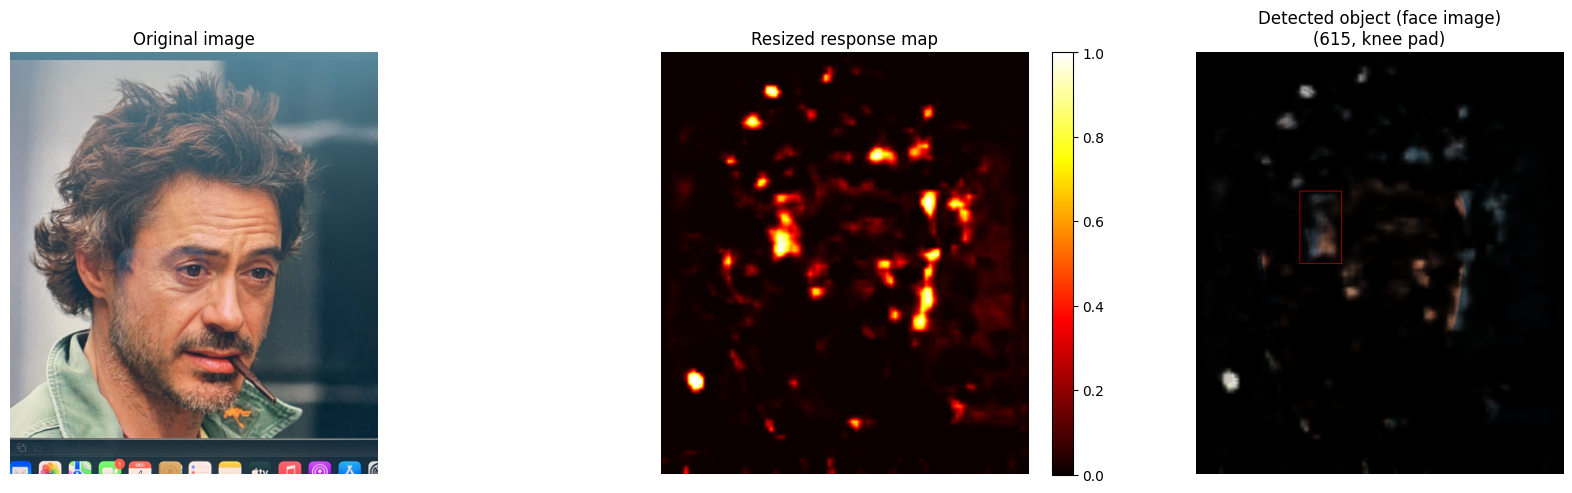


Image: /content/IMG_1113.jpg
Original size: 3008 x 3331
Response map shape: torch.Size([1, 1000, 105, 94])
Most activated class index: 699
Most activated class label: panpipe
score_map shape: (105, 94)
max(score) = 1.000, relative threshold = 0.150
Bounding box (x, y, w, h): (0, 1509, 1682, 230)


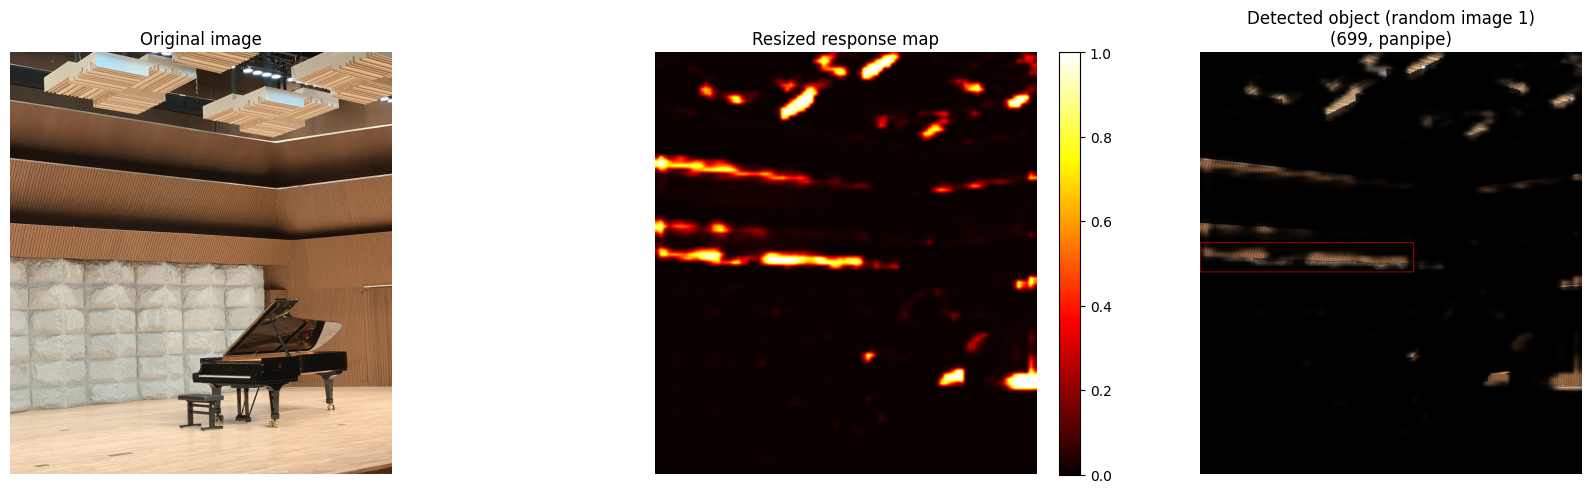


Image: /content/IMG_2074.jpg
Original size: 4032 x 3024
Response map shape: torch.Size([1, 1000, 95, 126])
Most activated class index: 906
Most activated class label: Windsor tie
score_map shape: (95, 126)
max(score) = 1.000, relative threshold = 0.150
Bounding box (x, y, w, h): (3560, 1187, 369, 446)


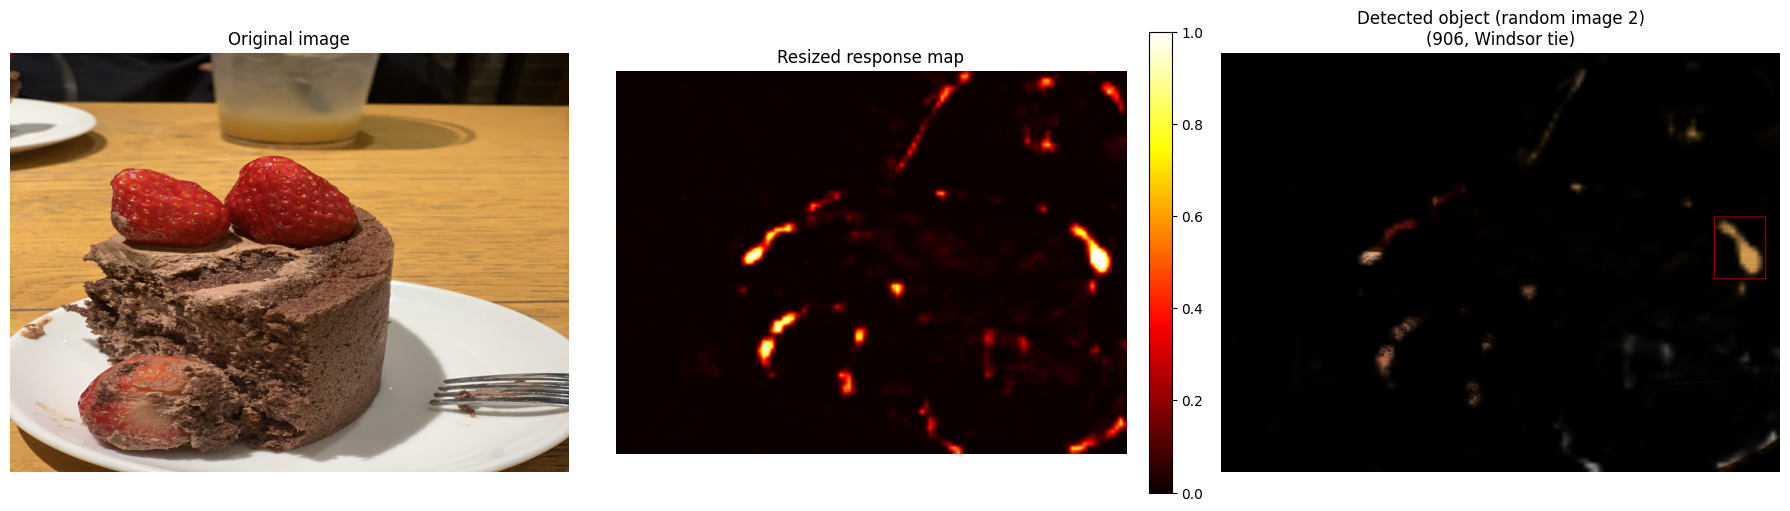


Summary for table:
Face: {'image_size': (3024, 3478), 'response_map_size': (109, 95), 'class_index': 615, 'class_label': 'knee pad'}
Random 1: {'image_size': (3008, 3331), 'response_map_size': (105, 94), 'class_index': 699, 'class_label': 'panpipe'}
Random 2: {'image_size': (4032, 3024), 'response_map_size': (95, 126), 'class_index': 906, 'class_label': 'Windsor tie'}


In [ ]:
# ---------- PART 5: face + two random images ----------

face_path    = "/content/IMG_3452.jpg"
random1_path = "/content/IMG_1113.jpg"
random2_path = "/content/IMG_2074.jpg"

info_face = auto_detect_and_show(
    face_path,
    title_prefix="Detected object (face image)",
    REL_THRESH=0.15,
    DILATE_SIZE=35,
)

info_r1 = auto_detect_and_show(
    random1_path,
    title_prefix="Detected object (random image 1)",
    REL_THRESH=0.15,
    DILATE_SIZE=35,
)

info_r2 = auto_detect_and_show(
    random2_path,
    title_prefix="Detected object (random image 2)",
    REL_THRESH=0.15,
    DILATE_SIZE=35,
)

print("\nSummary for table:")
print("Face:", info_face)
print("Random 1:", info_r1)
print("Random 2:", info_r2)